# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**

El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**: rentabilidad, comportamiento de usuarios y el impacto de un experimento A/B.

Se trabaja con múltiples fuentes de datos del negocio:

- **rappiplus_orders_raw.csv** → pedidos, precios, descuentos y revenue
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país
- **events / users / user_activity (SQL, PostgreSQL)** → comportamiento del usuario dentro de la plataforma
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout

**Herramientas:** Python (pandas, matplotlib, SciPy, statsmodels), SQL (PostgreSQL vía SQLAlchemy) y un dashboard en BI para la comunicación de resultados.

El análisis sigue una lógica progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)
2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)
3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión, SQL)
4. 🔁 Evaluar si los usuarios regresan (retención por cohortes, SQL)
5. 🧪 Validar si los cambios generan impacto (test estadístico A/B)
6. 📊 Comunicar los resultados (dashboard en BI)

A lo largo del proyecto se transforman datos crudos en insights accionables para responder preguntas clave del negocio.


---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [2]:
# importar librerías

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [3]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv")
marketing = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")

In [4]:
orders.info()  # explorar estructura general del dataset


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [5]:
orders.shape

(25100, 12)

In [6]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [7]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [8]:
# tu código aquí
orders["pais"].unique( )

array(['Argentina', 'Mexico', 'Colombia', 'mexico', 'colombia',
       'argentina', nan], dtype=object)

In [9]:
orders["pais"].str.capitalize( )

0        Argentina
1           Mexico
2        Argentina
3         Colombia
4        Argentina
           ...    
25095    Argentina
25096     Colombia
25097     Colombia
25098    Argentina
25099       Mexico
Name: pais, Length: 25100, dtype: object

In [10]:
orders["pais"] = orders["pais"].str.capitalize()

In [11]:
orders["pais"].unique( )

array(['Argentina', 'Mexico', 'Colombia', nan], dtype=object)

In [12]:
orders = orders.dropna(subset=["pais"])

In [13]:
orders["pais"].isna().sum()

0

In [14]:
orders["dispositivo"].unique( )

array(['desktop', 'mobile', nan], dtype=object)

In [15]:
orders = orders.dropna(subset=["dispositivo"])

In [16]:
orders["dispositivo"].isna().sum()

0

In [17]:
orders["categoria_producto"].unique( )

array(['Moda', 'Electronica', 'Hogar', nan], dtype=object)

In [18]:
orders["fuente_referencia"].unique( )

array(['organic', 'paid_search', 'social', nan], dtype=object)

In [19]:
orders = orders.dropna(subset=["dispositivo", "fuente_referencia", "nombre_producto", "categoria_producto", "cantidad", "precio_unitario", "monto_descuento"])

In [20]:
orders[[
    "dispositivo",
    "fuente_referencia",
    "nombre_producto",
    "categoria_producto",
    "cantidad",
    "precio_unitario",
    "monto_descuento"
]].isna().sum()

dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
dtype: int64

In [21]:
orders.isna().sum()

id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

In [22]:
diferencia = orders['monto_total'] - (orders['cantidad'] * orders['precio_unitario'] - orders['monto_descuento'])
diferencia.describe()

count    24700.000000
mean        -0.000033
std          0.004996
min         -0.010000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.010000
dtype: float64

In [23]:
marketing.isna().sum()

fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

In [24]:
marketing["canal"].unique()

array(['organic', 'paid_search', 'social', nan], dtype=object)

In [25]:
marketing = marketing.dropna(subset=["canal"])

In [26]:
marketing.isna().sum()

fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

In [27]:
catalog.isna().sum()

nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

In [28]:
catalog["categoria_producto"].unique()

array(['Electrónica', 'Hogar', 'Moda'], dtype=object)

In [29]:
catalog["proveedor"].unique()

array(['Fuller, Pena and Myers', 'King Ltd', 'Bowers LLC', 'Long-Reid',
       'Rivera, Carr and Finley', 'Greene-Smith', 'Mcmillan-Rhodes'],
      dtype=object)

In [30]:
catalog["costo_unitario"].unique()

array([280.68,  10.12,  25.21, 176.64,  16.6 ,  17.21, 189.31])

In [31]:
catalog["nombre_producto"].unique()

array(['Laptop-Gaming-16GB', 'Phone-Pro-128GB', 'Tablet-Standard-64GB',
       'Blender-XL-Red', 'Vacuum-Pro-Black', 'Sneakers-Urban-42',
       'Jacket-Winter-M'], dtype=object)

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [32]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [33]:
# tu código aquí
orders = orders.merge(
    catalog,
    on="nombre_producto",
    how="left"
)

In [34]:
orders[["nombre_producto", "costo_unitario"]].isna().sum()

nombre_producto    0
costo_unitario     0
dtype: int64

In [35]:
orders[orders["costo_unitario"].isna()]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto_x,cantidad,precio_unitario,monto_descuento,monto_total,categoria_producto_y,costo_unitario,proveedor


In [36]:
orders = orders.drop(columns=["categoria_producto_y"])

In [37]:
orders.columns

Index(['id_pedido', 'id_usuario', 'fecha_hora_pedido', 'pais', 'dispositivo',
       'fuente_referencia', 'nombre_producto', 'categoria_producto_x',
       'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total',
       'costo_unitario', 'proveedor'],
      dtype='object')

In [38]:
orders = orders.rename(columns={"categoria_producto_x": "categoria_producto"})

In [39]:
orders.columns

Index(['id_pedido', 'id_usuario', 'fecha_hora_pedido', 'pais', 'dispositivo',
       'fuente_referencia', 'nombre_producto', 'categoria_producto',
       'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total',
       'costo_unitario', 'proveedor'],
      dtype='object')

In [40]:
orders["ingreso"] = (
    orders["precio_unitario"] * orders["cantidad"]
) - orders["monto_descuento"]


In [41]:
orders[["precio_unitario", "cantidad", "monto_descuento"]].head()

,precio_unitario,cantidad,monto_descuento
0,332.69,2.0,0.0
1,176.86,1.0,5.0
2,102.99,2.0,10.0
3,257.87,1.0,15.0
4,336.28,1.0,0.0


In [42]:
orders["monto_total"].head()


0    665.37
1    171.86
2    195.99
3    242.87
4    336.28
Name: monto_total, dtype: float64

In [43]:
orders["ingreso"].head()

0    665.38
1    171.86
2    195.98
3    242.87
4    336.28
Name: ingreso, dtype: float64

In [44]:
ingreso_total = orders["ingreso"].sum()
print(ingreso_total)

51873171.24999999


In [45]:
orders["costo_total"] = (
    orders["costo_unitario"] * orders["cantidad"]
)

In [46]:
orders[["costo_unitario", "cantidad", "costo_total"]].head()

,costo_unitario,cantidad,costo_total
0,189.31,2.0,378.62
1,25.21,1.0,25.21
2,176.64,2.0,353.28
3,25.21,1.0,25.21
4,176.64,1.0,176.64


In [47]:
costo_total = orders["costo_total"].sum()

print(costo_total)

43095280.85


In [48]:
marketing_total = marketing["gasto"].sum()
print(marketing_total)

2694664.4299999997


In [49]:

profit = ingreso_total - costo_total - marketing_total
print(profit)


6083225.969999991


In [50]:

profit_margin = (profit / ingreso_total) * 100

print(f"Margen de ganancia: {profit_margin:.2f}%")


Margen de ganancia: 11.73%


In [51]:
orders.groupby("categoria_producto")

In [52]:
rentabilidad_categoria = (
    orders
    .groupby("categoria_producto")[["ingreso", "costo_total"]]
    .sum()
)

rentabilidad_categoria

,ingreso,costo_total
categoria_producto,,
Electronica,45527876.91,4.061418e+07
Hogar,3204526.98,1.200452e+06
Moda,3140767.36,1.280648e+06


In [53]:
rentabilidad_categoria["profit"] = (
    rentabilidad_categoria["ingreso"]
    - rentabilidad_categoria["costo_total"]
)
print(rentabilidad_categoria["profit"])

categoria_producto
Electronica    4.913696e+06
Hogar          2.004075e+06
Moda           1.860120e+06
Name: profit, dtype: float64


In [54]:
rentabilidad_categoria["profit_margin"] = (
    rentabilidad_categoria["profit"]
    / rentabilidad_categoria["ingreso"]
) * 100
print(rentabilidad_categoria["profit_margin"])

categoria_producto
Electronica    10.792719
Hogar          62.538871
Moda           59.225005
Name: profit_margin, dtype: float64


In [55]:
rentabilidad_categoria.sort_values(
    by="profit_margin",
    ascending=False
)

,ingreso,costo_total,profit,profit_margin
categoria_producto,,,,
Hogar,3204526.98,1.200452e+06,2.004075e+06,62.538871
Moda,3140767.36,1.280648e+06,1.860120e+06,59.225005
Electronica,45527876.91,4.061418e+07,4.913696e+06,10.792719


In [56]:
rentabilidad_categoria["costo_porcentaje"] = (
    rentabilidad_categoria["costo_total"]
    / rentabilidad_categoria["ingreso"]
) * 100
print(rentabilidad_categoria["costo_porcentaje"])

categoria_producto
Electronica    89.207281
Hogar          37.461129
Moda           40.774995
Name: costo_porcentaje, dtype: float64


# Visualizacion de rentabilidad por categoria
Las siguientes graficas complementan los KPIs y permiten comparar el aporte absoluto y relativo de cada categoria.

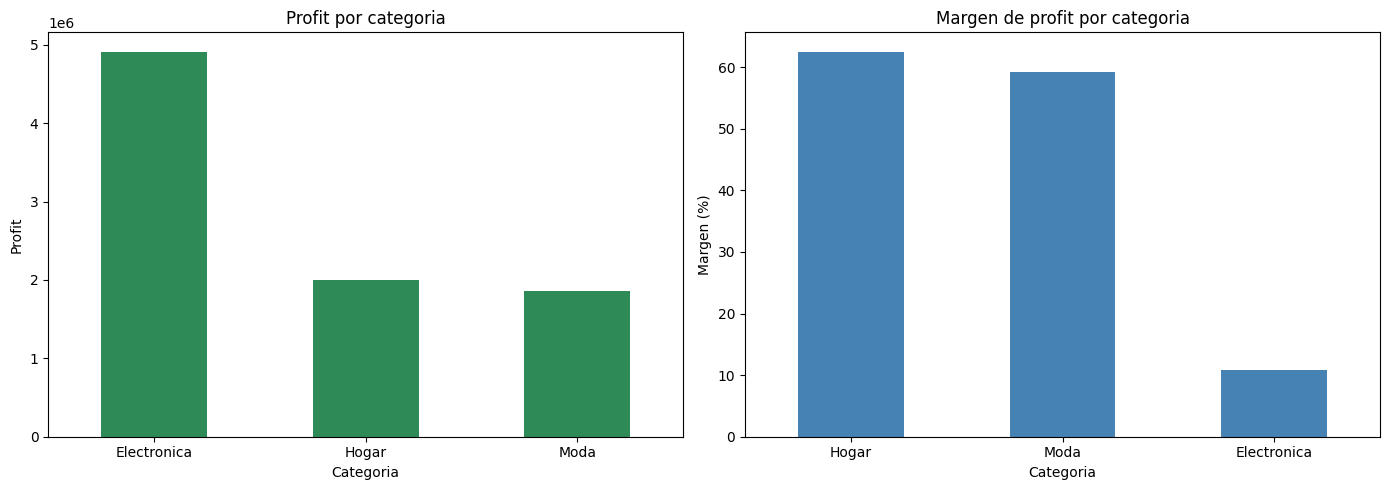

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rentabilidad_categoria.sort_values('profit', ascending=False)['profit'].plot(
    kind='bar', ax=axes[0], color='#2E8B57'
)
axes[0].set_title('Profit por categoria')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Profit')
axes[0].tick_params(axis='x', rotation=0)

rentabilidad_categoria.sort_values('profit_margin', ascending=False)['profit_margin'].plot(
    kind='bar', ax=axes[1], color='#4682B4'
)
axes[1].set_title('Margen de profit por categoria')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Margen (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Interpretacion
Electronica aporta el mayor profit absoluto por su volumen de ventas, aunque su margen es el menor. Hogar y Moda tienen margenes notablemente mas altos; por ello, conviene mantener el volumen de Electronica mientras se evalua incrementar la participacion de las categorias de mayor margen, sin perder de vista la demanda y los costos de marketing.

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [58]:
import pandas as pd
from sqlalchemy import create_engine
import os

# ======================
# Conexión a la base de datos
# ======================
# Credenciales de la base de entrenamiento provista por TripleTen.
# Se omite la contraseña real por buenas prácticas de seguridad al publicar
# este notebook; si vas a re-ejecutarlo, define DB_PWD como variable de entorno.
db_config = {
    'user': 'practicum_student',
    'pwd': os.getenv('DB_PWD', '<tu_password_aqui>'),
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})


In [59]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [60]:
query = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY
CASE
    WHEN nombre_evento = 'first_visit' THEN 1
    WHEN nombre_evento = 'select_item' THEN 2
    WHEN nombre_evento = 'add_to_cart' THEN 3
    WHEN nombre_evento = 'begin_checkout' THEN 4
    WHEN nombre_evento = 'add_payment_info' THEN 5
    WHEN nombre_evento = 'purchase' THEN 6
END;
'''


In [61]:
resultado = pd.read_sql(query, engine)

resultado

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,select_item,7582
2,add_to_cart,7634
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [62]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios
    FROM events
    GROUP BY nombre_evento
)

SELECT
    nombre_evento,
    usuarios,
    COALESCE(
        ROUND(
            usuarios * 100.0 /
            LAG(usuarios) OVER (
                ORDER BY CASE
                    WHEN nombre_evento = 'first_visit' THEN 1
                    WHEN nombre_evento = 'select_item' THEN 2
                    WHEN nombre_evento = 'add_to_cart' THEN 3
                    WHEN nombre_evento = 'begin_checkout' THEN 4
                    WHEN nombre_evento = 'add_payment_info' THEN 5
                    WHEN nombre_evento = 'purchase' THEN 6
                END
            ),
            2
        ),
        100.00
    ) AS conversion_pct
FROM funnel
ORDER BY CASE
    WHEN nombre_evento = 'first_visit' THEN 1
    WHEN nombre_evento = 'select_item' THEN 2
    WHEN nombre_evento = 'add_to_cart' THEN 3
    WHEN nombre_evento = 'begin_checkout' THEN 4
    WHEN nombre_evento = 'add_payment_info' THEN 5
    WHEN nombre_evento = 'purchase' THEN 6
END
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios,conversion_pct
0,first_visit,7796,100.00
1,select_item,7582,97.26
2,add_to_cart,7634,100.69
3,begin_checkout,7208,94.42
4,add_payment_info,6250,86.71
5,purchase,6240,99.84


In [63]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH conversion AS (
    SELECT *
    FROM (
        VALUES
            (1, 'first_visit', 7796),
            (2, 'select_item', 7582),
            (3, 'add_to_cart', 7634),
            (4, 'begin_checkout', 7208),
            (5, 'add_payment_info', 6250),
            (6, 'purchase', 6240)
    ) AS t(orden, nombre_evento, usuarios)
),

funnel AS (
    SELECT
        orden,
        nombre_evento,
        usuarios,
        LAG(nombre_evento) OVER (ORDER BY orden) AS evento_anterior,
        LAG(usuarios) OVER (ORDER BY orden) AS usuarios_anterior
    FROM conversion
)

SELECT
    CONCAT(evento_anterior, ' → ', nombre_evento) AS transicion,
    usuarios_anterior - usuarios AS usuarios_perdidos,
    ROUND(
        ((usuarios_anterior - usuarios)::NUMERIC / usuarios_anterior) * 100,
        2
    ) AS tasa_abandono_pct
FROM funnel
WHERE evento_anterior IS NOT NULL
ORDER BY orden;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,transicion,usuarios_perdidos,tasa_abandono_pct
0,first_visit → select_item,214,2.74
1,select_item → add_to_cart,-52,-0.69
2,add_to_cart → begin_checkout,426,5.58
3,begin_checkout → add_payment_info,958,13.29
4,add_payment_info → purchase,10,0.16


# Correccion del funnel
El calculo anterior contaba usuarios de cada evento de manera independiente, por lo que una etapa podia tener mas usuarios que la anterior. A continuacion se cuenta unicamente a quienes completaron todas las etapas previas; asi el funnel es acumulado y sus valores son necesariamente decrecientes.

,evento,usuarios,conversion_desde_inicio_pct,conversion_entre_pasos_pct,abandono_entre_pasos_pct
0,first_visit,7796,100.00,100.00,0.00
1,select_item,7393,94.83,94.83,5.17
2,add_to_cart,7052,90.46,95.39,4.61
3,begin_checkout,6364,81.63,90.24,9.76
4,add_payment_info,4967,63.71,78.05,21.95
5,purchase,3857,49.47,77.65,22.35


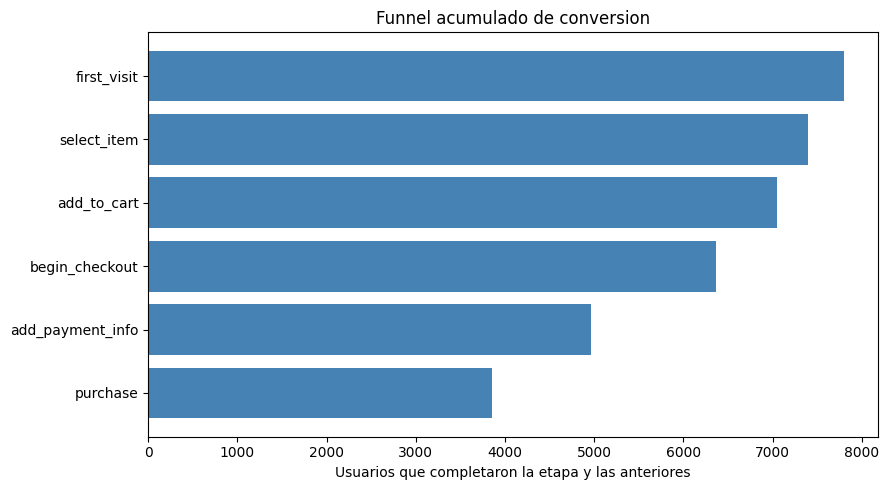

In [73]:
pasos_funnel = [
    'first_visit', 'select_item', 'add_to_cart',
    'begin_checkout', 'add_payment_info', 'purchase'
]

# Eventos observados por usuario. Cada etapa exige haber completado todas las anteriores.
eventos_por_usuario = (
    events.groupby('id_usuario')['nombre_evento']
    .agg(set)
)

requeridos = set()
filas_funnel = []
for paso in pasos_funnel:
    requeridos.add(paso)
    usuarios = sum(requeridos.issubset(eventos_usuario) for eventos_usuario in eventos_por_usuario)
    filas_funnel.append({'evento': paso, 'usuarios': usuarios})

funnel_corregido = pd.DataFrame(filas_funnel)
funnel_corregido['conversion_desde_inicio_pct'] = (
    funnel_corregido['usuarios'] / funnel_corregido.loc[0, 'usuarios'] * 100
).round(2)
funnel_corregido['conversion_entre_pasos_pct'] = (
    funnel_corregido['usuarios'] / funnel_corregido['usuarios'].shift(1) * 100
).fillna(100).round(2)
funnel_corregido['abandono_entre_pasos_pct'] = (
    100 - funnel_corregido['conversion_entre_pasos_pct']
).round(2)

display(funnel_corregido)

plt.figure(figsize=(9, 5))
plt.barh(funnel_corregido['evento'], funnel_corregido['usuarios'], color='#4682B4')
plt.gca().invert_yaxis()
plt.title('Funnel acumulado de conversion')
plt.xlabel('Usuarios que completaron la etapa y las anteriores')
plt.tight_layout()
plt.show()

# Interpretacion
La tabla y la grafica deben leerse de forma acumulada: la conversion desde el inicio disminuye en cada etapa porque solo se conservan usuarios que completaron el recorrido anterior. La transicion con el mayor abandono identifica el principal punto de friccion para priorizar mejoras de producto. Se recomienda revisar ese paso por dispositivo, pais y fuente de referencia antes de proponer cambios.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [64]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [65]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [66]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
SELECT
    DATE_TRUNC('month', CAST(u.fecha_registro AS DATE))::DATE AS cohorte,

    COUNT(DISTINCT u.id_usuario) AS usuarios_iniciales,

    COUNT(DISTINCT CASE
        WHEN ua.dias_despues_registro = 7
        AND ua.activo = 1
        THEN ua.id_usuario
    END) AS retenido_w1,

    COUNT(DISTINCT CASE
        WHEN ua.dias_despues_registro = 14
        AND ua.activo = 1
        THEN ua.id_usuario
    END) AS retenido_w2,

    COUNT(DISTINCT CASE
        WHEN ua.dias_despues_registro = 21
        AND ua.activo = 1
        THEN ua.id_usuario
    END) AS retenido_w3,

    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 7
            AND ua.activo = 1
            THEN ua.id_usuario
        END) / COUNT(DISTINCT u.id_usuario),
        2
    ) AS semana_1,

    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 14
            AND ua.activo = 1
            THEN ua.id_usuario
        END) / COUNT(DISTINCT u.id_usuario),
        2
    ) AS semana_2,

    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 21
            AND ua.activo = 1
            THEN ua.id_usuario
        END) / COUNT(DISTINCT u.id_usuario),
        2
    ) AS semana_3

FROM users AS u

LEFT JOIN user_activity AS ua
    ON u.id_usuario = ua.id_usuario

GROUP BY DATE_TRUNC('month', CAST(u.fecha_registro AS DATE))::DATE

ORDER BY cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01,1687,695,676,706,41.20,40.07,41.85


## Visualizacion de retencion por cohorte

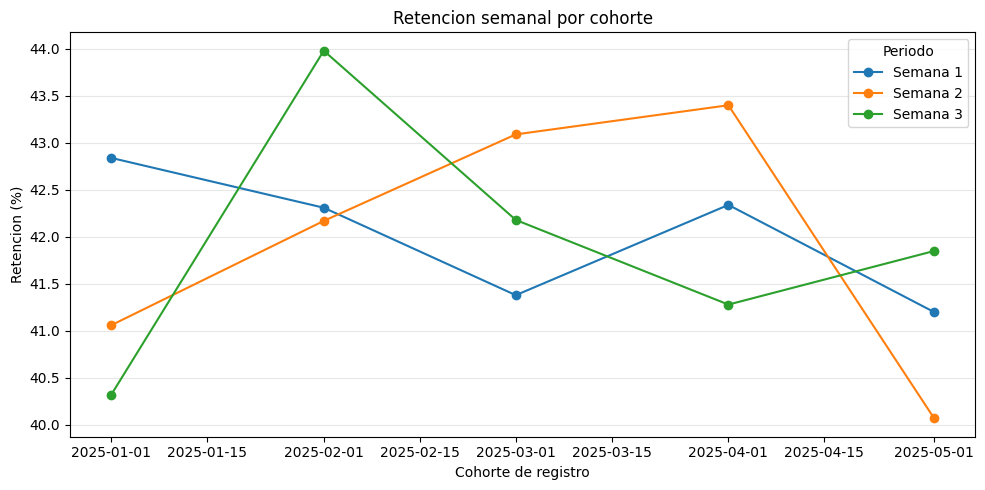

In [74]:
retencion_plot = cohorte_final.set_index('cohorte')[['semana_1', 'semana_2', 'semana_3']]

ax = retencion_plot.plot(kind='line', marker='o', figsize=(10, 5))
ax.set_title('Retencion semanal por cohorte')
ax.set_xlabel('Cohorte de registro')
ax.set_ylabel('Retencion (%)')
ax.legend(['Semana 1', 'Semana 2', 'Semana 3'], title='Periodo')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretacion
La grafica permite comparar la retencion de las cohortes a la semana 1, 2 y 3. Antes de atribuir una variacion a una accion de negocio, se debe contrastar con cambios en adquisicion, producto o estacionalidad. Las cohortes con caidas sostenidas son candidatas para analizar onboarding, comunicaciones de reactivacion y experiencia de checkout.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión es igual entre el grupo control y el grupo tratamiento. El cambio en la UI del checkout no genera una diferencia estadísticamente significativa en la conversión.
   - **H₁ (Hipótesis alternativa):** La tasa de conversión es diferente entre el grupo control y el grupo tratamiento. El cambio en la UI del checkout genera una diferencia estadísticamente significativa en la conversión.
   
**Test estadístico:**  Prueba de proporciones de dos muestras (z-test). 

**Nivel de significancia alpha:**  0.05

In [67]:
experiment = pd.read_csv(
    "https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv"
)

# Revisar las primeras filas
experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [68]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [69]:
experiment.columns

Index(['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais',
       'duracion_sesion', 'timestamp'],
      dtype='object')

In [70]:
# Revisar las variantes del experimento
print(experiment['variante'].value_counts())

tratamiento    5035
control        4965
Name: variante, dtype: int64


In [71]:
# Calcular tasa de conversión por variante
conversion = experiment.groupby('variante')['convirtio'].agg(['count', 'sum', 'mean'])

conversion

,count,sum,mean
variante,,,
control,4965,779,0.156898
tratamiento,5035,820,0.162860


In [72]:
from statsmodels.stats.proportion import proportions_ztest

# Conversiones en cada grupo
conversiones = [
    experiment[experiment['variante'] == 'control']['convirtio'].sum(),
    experiment[experiment['variante'] == 'tratamiento']['convirtio'].sum()
]

# Número de usuarios en cada grupo
usuarios = [
    (experiment['variante'] == 'control').sum(),
    (experiment['variante'] == 'tratamiento').sum()
]

# Aplicar prueba de proporciones
estadistico, p_value = proportions_ztest(conversiones, usuarios)

print("Estadístico z:", estadistico)
print("p-value:", p_value)

Estadístico z: -0.8132782986429474
p-value: 0.41605851639119995


### Interpretación del resultado

La tasa de conversión del grupo control fue de 15.69%, mientras que la del grupo tratamiento fue de 16.29%. Aunque se observa un incremento de aproximadamente 0.60 puntos porcentuales en el grupo tratamiento, esta diferencia no es estadísticamente significativa.

El test de proporciones obtuvo un estadístico z de -0.8133 y un p-value de 0.4161. Como el p-value es mayor que el nivel de significancia establecido (α = 0.05), no se rechaza la hipótesis nula (H₀).

Por lo tanto, no existe evidencia estadísticamente significativa para afirmar que el cambio realizado en la interfaz del checkout haya generado un impacto en la tasa de conversión.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 📊 Dashboard

Los hallazgos de este análisis se comunicaron a través de un dashboard interactivo (Power BI / Tableau) que resume rentabilidad, funnel de conversión, retención por cohortes y los resultados del experimento A/B.

🔗 [Ver dashboard](https://drive.google.com/file/d/1jbbx0fVHAmqCqqBl7bqz65B7qDYP6sA6/view?usp=drive_link)


### Insight Ejecutivo: El crecimiento rentable está en optimizar el checkout y mejorar el mix de categorías

RappiPlus genera 6.08M de profit, equivalente a un **11.73 porciento** de margen sobre el ingreso. Sin embargo, la rentabilidad presenta diferencias importantes entre categorías: Electrónica concentra el mayor volumen y aporta **4.91M de profit**, pero con un margen de solo **10.79 porciento**, mientras que Hogar (62.54 porciento) y Moda (59.23 porciento) presentan márgenes significativamente superiores.

Al mismo tiempo, existe una oportunidad relevante para capturar más valor de la demanda actual. De 7,796 usuarios que ingresan al sitio, 3,857 completan una compra, equivalente a una conversión final de **49.47 porciento**. Las principales fugas del funnel se concentran en begin_checkout → add_payment_info **(21.95 porciento)** y add_payment_info → purchase **(22.35 porciento)**, lo que indica que una proporción relevante de usuarios abandona durante las etapas finales del proceso de compra.

La oportunidad no está únicamente en adquirir más usuarios, sino en convertir una mayor proporción de la demanda existente y mejorar la rentabilidad del mix vendido. Por ello, la prioridad debería ser investigar y **optimizar el checkout, segmentando el análisis por dispositivo, país y fuente de referencia para identificar dónde se concentra el abandono.**

En paralelo, RappiPlus podría incrementar la participación de categorías de mayor margen, como Hogar y Moda, mediante recomendaciones, promociones y estrategias de cross-selling, sin reducir la importancia de Electrónica como principal generadora de volumen y profit.

El experimento de UI analizado no presenta evidencia estadísticamente significativa de mejora en conversión (p = 0.416), por lo que no se recomienda escalarlo con la evidencia actual. En su lugar, los siguientes experimentos deberían concentrarse específicamente en los dos puntos críticos del checkout y **evaluar no solo el incremento de conversión, sino también su impacto sobre profit, margen y desempeño por segmento.**

Prioridad estratégica: primero reducir la fricción en checkout; después, utilizar ese tráfico convertido para impulsar categorías de mayor margen. De esta manera, el crecimiento puede venir no solo de vender más, sino de convertir mejor y vender de forma más rentable.